In [1]:
#Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the datasets
(x_train,y_train),(x_test,y_test)=mnist.load_data()
#Preprocess the datasets
x_train,x_test=x_train/255.0,x_test/255.0
y_train,y_test=to_categorical(y_train),to_categorical(y_test)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1 so we will re-download the data.
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 198s 17us/step


In [5]:
#Convolutional Network
model=Sequential([
    Conv2D(64,3,activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(64,3,activation='relu'),
    MaxPooling2D(),
    Conv2D(64,3,activation='relu'),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [7]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5,batch_size=64,validation_data=(x_test,y_test))
test_loss,test_acc=model.evaluate(x_test,y_test)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9435 - loss: 0.1796 - val_accuracy: 0.9827 - val_loss: 0.0537
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.9880 - val_loss: 0.0359
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9892 - val_loss: 0.0334
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9904 - val_loss: 0.0320
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9936 - loss: 0.0215 - val_accuracy: 0.9896 - val_loss: 0.0322
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9896 - loss: 0.0322


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


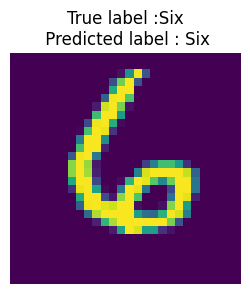

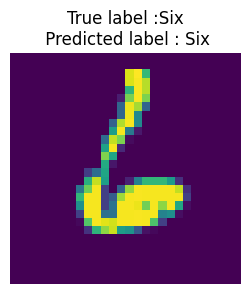

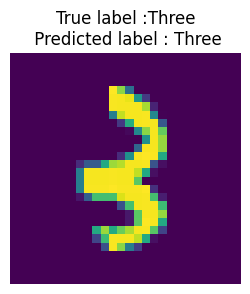

Test accuracy : 0.9896000027656555
 Test loss : 0.03220418095588684


In [10]:
#Predicting values based on the model
class_names=['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
random_indices=np.random.choice(len(x_test),3,replace=False)
sample_images=x_test[random_indices]
sample_labels=y_test[random_indices]
predictions=model.predict(sample_images)
#Display the result
for i in range(3):
    plt.figure(figsize=(10,3))
    predicted_label=class_names[np.argmax(predictions[i])]
    true_label=class_names[np.argmax(sample_labels[i])]
    plt.imshow(sample_images[i])
    plt.title(f'True label :{true_label}\n Predicted label : {predicted_label}')
    plt.axis('off')
    plt.show()
print(f'Test accuracy : {test_acc}\n Test loss : {test_loss}')